# Plot the results of subclone interaction term estimations (error)

This file loads the results of the estimations for $k$ and $m$, subsets them to those that satisfy the biological constraints, and generates Figure 3d.

## Prep

Load needed packages

In [1]:
%matplotlib widget
from matplotlib import pyplot as plt
import pandas as pd
import numpy as np
import math
import seaborn as sns
import os
from statsmodels.formula import api as smf
from estimator import Estimator
pd.options.mode.chained_assignment = None

Close any figures generated from previous runs

In [2]:
plt.close("all")

## Define data and user-input parameters

Define the file path for the configuration file (which contains the path to the growth data and estimated growth rates of the subclones), the result path, save path, and names of nude groups.

In [3]:
groups = ["Grp. B2 nude (80% C1; 20% C11)", "Grp. B3 nude (50% C1; 50% C11)", "Grp. B4 nude (20% C1; 80% C11)"]
result_path = "../estimators/exhs_km/"
config = "config_subclone.json"
avg_save_file = "result_km_avg.csv"
fig_save_file = "figures/nude_km.svg"

Create an Estimator object from the config file

In [4]:
es = Estimator(config)

Function to get the initial ratio of the subclones based on the group name

In [5]:
def get_init(group):
    if "A1" in group or "B1" in group: return [1, 0]
    if "A2" in group or "B2" in group: return [0.8, 0.2]
    if "A3" in group or "B3" in group: return [0.5, 0.5]
    if "A4" in group or "B4" in group: return [0.2, 0.8]
    if "A5" in group or "B5" in group: return [0, 1]

## Load and subset the results

Loop through all the result files and create a data frame

In [6]:
results = []
for fname in [f for f in os.listdir(result_path) if ".csv" in f]:
    temp = pd.read_csv("{}/{}".format(result_path, fname))
    results += [temp]
results = pd.concat(results, ignore_index=True).drop_duplicates()
results

,group,id,k,m,winner,error
0,Grp. B2 nude (80% C1; 20% C11),460,0.000,-0.200,0.0,43.560244
1,Grp. B2 nude (80% C1; 20% C11),460,0.050,-0.200,0.0,61.570258
2,Grp. B2 nude (80% C1; 20% C11),461,0.000,-0.200,0.0,12.114868
3,Grp. B2 nude (80% C1; 20% C11),461,0.050,-0.200,0.0,9.416198
4,Grp. B2 nude (80% C1; 20% C11),462,0.000,-0.200,0.0,249.203283
...,...,...,...,...,...,...
945017,Grp. B4 nude (20% C1; 80% C11),477,0.129,-0.205,0.0,3.995679
945018,Grp. B4 nude (20% C1; 80% C11),477,0.129,-0.204,0.0,4.168657
945019,Grp. B4 nude (20% C1; 80% C11),477,0.129,-0.203,0.0,4.349955
945020,Grp. B4 nude (20% C1; 80% C11),477,0.129,-0.202,0.0,4.539787


Subset the results to those where all mice have mean squared error in the top 50th percentile 

In [7]:
# Make a copy of the results data frame so we maintain the original
temp = results.copy()
# For each mouse, determine which pairs have error in the top 50th percentile of errors (of that mouse)
temp["top_quantile"] = results.groupby("id")["error"].transform(lambda x: x < np.quantile(x, 0.5))
# For each k, m pair, determine if every mouse has error in the top 50th percentile
temp1 = temp.groupby(["k", "m"]).apply(lambda x: all(x["top_quantile"])).reset_index()
# Calculate the average values of each parameter combination 
temp2 = results.groupby(["k", "m"])["error"].mean().reset_index()
# Merge the average error data frame and that containing the percentile information
avg_results = pd.merge(temp1, temp2, on=["k", "m"]).drop_duplicates()
avg_results

,k,m,0,error
0,0.0,-0.250,False,1.615369e+02
1,0.0,-0.249,False,1.615347e+02
2,0.0,-0.248,False,1.615324e+02
3,0.0,-0.247,False,1.615301e+02
4,0.0,-0.246,False,1.615278e+02
...,...,...,...,...
50245,0.2,-0.005,False,1.396062e+05
50246,0.2,-0.004,False,2.115673e+05
50247,0.2,-0.003,False,3.586157e+05
50248,0.2,-0.002,False,7.396082e+05


## Plot (Figure 3d)

In order to make the range of values to plot such that the gradient is visible, set the maximum possible error value to the largest error among the m, k pairs in the top 50th percentiles

In [8]:
# Find the max error of the points that satisfy the constraints
max_err = avg_results[avg_results[0]]["error"].max()
# If the error is larger than the max error, set to max error 
# (now all points that do not satisfy constraints will be set to the maximum error)
avg_results["error"] = [min(e, max_err) for e in avg_results["error"]]

In [9]:
avg_results[avg_results["error"] != max_err].to_csv(avg_save_file)

In [10]:
avg_results[avg_results["error"] != max_err]

,k,m,0,error
217,0.0,-0.033,False,NaN
218,0.0,-0.032,False,NaN
219,0.0,-0.031,False,NaN
220,0.0,-0.030,False,NaN
221,0.0,-0.029,False,NaN
...,...,...,...,...
50052,0.2,-0.198,False,49.543671
50053,0.2,-0.197,False,49.768919
50054,0.2,-0.196,False,50.003689
50055,0.2,-0.195,False,50.248265


Pivot the data frame for plotting

In [11]:
avg_results_pivot = pd.pivot(avg_results, index="k", columns="m", values="error").sort_index(ascending=False)

Plot average error

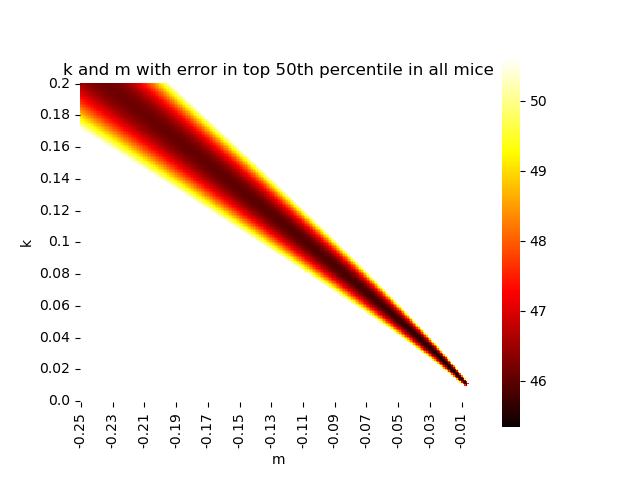

In [12]:
fig, ax = plt.subplots(nrows=1, ncols=1)
sns.heatmap(avg_results_pivot, ax=ax, yticklabels=[round(j, 3) for j in avg_results_pivot.index], xticklabels=[round(j, 3) for j in avg_results_pivot.columns], square=True, cmap="hot")
# Here we subset the labels so they don't overlap; if you have fewer points, comment these two lines
ax.set_yticks(ax.get_yticks()[::20]) 
ax.set_xticks(ax.get_xticks()[::20])
plt.title("k and m with error in top 50th percentile in all mice")
if fig_save_file:
    plt.savefig(fig_save_file)

## Linear regression between $k$ and $m$ points with low error

In [13]:
lr_res = smf.ols("k~m", data=avg_results[avg_results[0]]).fit()
lr_res.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      k   R-squared:                       0.994
Model:                            OLS   Adj. R-squared:                  0.994
Method:                 Least Squares   F-statistic:                 2.744e+05
Date:                Tue, 25 Nov 2025   Prob (F-statistic):               0.00
Time:                        10:25:41   Log-Likelihood:                 7153.2
No. Observations:                1609   AIC:                        -1.430e+04
Df Residuals:                    1607   BIC:                        -1.429e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0086      0.000     35.271      0.000       0.008       0.009
m             -0.7051      0.001   -523.791      0.000      -0.708      -0.703
==============================================================================
Omnibus:                      114.727   Durbin-Watson:                   0.724
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               39.796
Skew:                          -0.028   Prob(JB):                     2.28e-09
Kurtosis:                       2.232   Cond. No.                         19.6
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

Find maximum value of $m$

In [14]:
avg_results[avg_results[0]]["m"].max()

-0.033